In [1]:
import cv2
from image_stitching.main import load_images_from_folder
from matplotlib import pyplot as plt 

In [227]:
imgs = load_images_from_folder(r"..\raw_images\input_5")

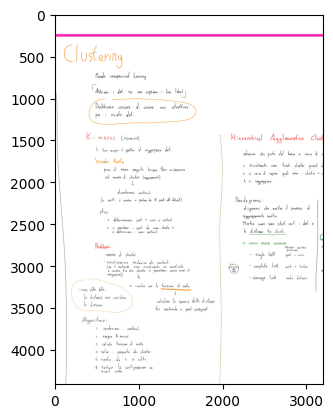

In [3]:
plt.imshow(cv2.cvtColor(imgs[0], cv2.COLOR_BGR2RGB))

In [4]:
base_img = imgs[0]
gray_base = cv2.cvtColor(base_img, cv2.COLOR_BGR2GRAY)

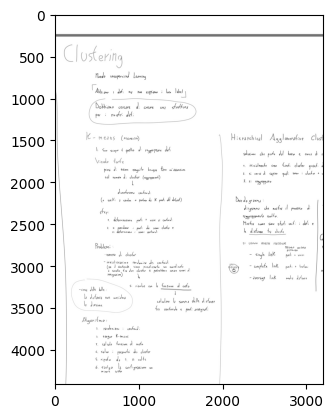

In [5]:
plt.imshow(gray_base, cmap='grey', vmin=0, vmax=255)

In [6]:
# edge detection
gray = cv2.cvtColor(base_img, cv2.COLOR_BGR2GRAY)
equalize_hist_gray = cv2.equalizeHist(gray)
gaussian_blur_gray = cv2.GaussianBlur(gray, (3,3), 0)

equalize_hist_edges = cv2.Canny(equalize_hist_gray, 30, 90)
gaussian_blur_edges = cv2.Canny(gaussian_blur_gray, 30, 90)

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
fig.suptitle('Edge detection')

ax1.imshow(equalize_hist_edges, cmap='grey', vmin=0, vmax=255)
ax1.set_title("Edge detection based on equalizeHist()")

ax2.imshow(gaussian_blur_edges, cmap='grey', vmin=0, vmax=255)
ax2.set_title("Edge detection based on GaussianBlur() with 3x3 kernel")

plt.tight_layout()
plt.show()

In [141]:
import cv2
import numpy as np


def merge_by_translation(base_img, new_img, x_dir = 1, y_dir = 1):
    """
    Merge di due immagini assumendo:
    - stessa scala
    - stessa rotazione
    - solo traslazione

    Gestisce shift positivi e negativi.
    
    Ritorna:
        merged_image
        (dx, dy)
        response
    """

    # Convert to grayscale float32 (richiesto da phaseCorrelate)
    gray_base = cv2.cvtColor(base_img, cv2.COLOR_BGR2GRAY)
    gray_new = cv2.cvtColor(new_img, cv2.COLOR_BGR2GRAY)

    """
    # blur
    gray_base_blured = cv2.GaussianBlur(gray_base, (3,3), 0)
    gray_new_blured = cv2.GaussianBlur(gray_new, (3,3), 0)
    
    # edge detection
    edges_base = cv2.Canny(gray_base_blured, 30, 90)
    edges_new  = cv2.Canny(gray_new_blured, 30, 90)

    # Per usare phaseCorrelate devono avere stessa dimensione.
    # Quindi le portiamo su un canvas comune temporaneo.
    h = max(edges_base.shape[0], edges_new.shape[0])
    w = max(edges_base.shape[1], edges_new.shape[1])

    pad_base = np.zeros((h, w), dtype=np.float32)
    pad_new = np.zeros((h, w), dtype=np.float32)

    pad_base[:edges_base.shape[0], :edges_base.shape[1]] = edges_base
    pad_new[:edges_new.shape[0], :edges_new.shape[1]] = edges_new
    """
    
    gray_base = cv2.GaussianBlur(gray_base, (3,3), 0)
    gray_new  = cv2.GaussianBlur(gray_new, (3,3), 0)

    h = max(gray_base.shape[0], gray_new.shape[0])
    w = max(gray_base.shape[1], gray_new.shape[1])

    pad_base = np.zeros((h, w), dtype=np.float32)
    pad_new = np.zeros((h, w), dtype=np.float32)

    # centrare nel canvas
    y_off_base = (h - gray_base.shape[0]) // 2
    x_off_base = (w - gray_base.shape[1]) // 2
    
    y_off_new = (h - gray_new.shape[0]) // 2
    x_off_new = (w - gray_new.shape[1]) // 2
    
    pad_base[y_off_base:y_off_base + gray_base.shape[0],
             x_off_base:x_off_base + gray_base.shape[1]] = gray_base
    
    pad_new[y_off_new:y_off_new + gray_new.shape[0],
            x_off_new:x_off_new + gray_new.shape[1]] = gray_new
        
    # Calcolo shift tramite applicazione finestra di Hanning 
    window = cv2.createHanningWindow((w, h), cv2.CV_32F)
    shift, response = cv2.phaseCorrelate(pad_base, pad_new, window)

    dx, dy = shift
    dx = -int(round(dx)) 
    dy = -int(round(dy))

    # Calcolo coordinate min/max considerando shift
    h_base, w_base = base_img.shape[:2]
    h_new, w_new = new_img.shape[:2]

    x_min = min(0, dx)
    y_min = min(0, dy)
    x_max = max(w_base, dx + w_new)
    y_max = max(h_base, dy + h_new)

    canvas_w = x_max - x_min
    canvas_h = y_max - y_min

    # Offset per rendere tutto positivo
    offset_x = -x_min
    offset_y = -y_min

    canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)

    # Inserisci base
    canvas[offset_y:offset_y + h_base,
           offset_x:offset_x + w_base] = base_img

    # Inserisci new
    canvas[offset_y + dy:offset_y + dy + h_new,
           offset_x + dx:offset_x + dx + w_new] = new_img

    return canvas, (dx, dy), response

## Test funzionalità su immagini singole

In [142]:
def compute_merge_with_log(base, new_img, iteration, x_direction = 1, y_direction = 1):
    print(f"Iteration {iteration}:")
    merged, shift, response = merge_by_translation(base, new_img, x_direction, y_direction)
    print("Shift:", shift)
    print("Response:", response)
    return merged

In [ ]:
%matplotlib qt

In [157]:
plt.figure(1) 
plt.imshow(imgs[0])

plt.figure(2) 
plt.imshow(imgs[1])
plt.tight_layout()
plt.show()

In [158]:
merged_1 =  compute_merge_with_log(imgs[0], imgs[1], 0, 1, 1)

Iteration 0:
Shift: (-12, 1183)
Response: 0.6502291187710232


In [159]:
plt.figure(3) 
plt.imshow(merged_1)
plt.tight_layout()
plt.show()

In [160]:
plt.figure(4) 
plt.imshow(imgs[2])
plt.tight_layout()

In [161]:
merged_2 =  compute_merge_with_log(imgs[0], imgs[2], 0, 1, 1)

Iteration 0:
Shift: (753, -116)
Response: 0.5783117152235243


In [162]:
plt.figure(5) 
plt.imshow(merged_2)
plt.tight_layout()

In [163]:
merged_3 =  compute_merge_with_log(merged_1, merged_2, 0)

Iteration 0:
Shift: (382, -649)
Response: 0.7826595020507813


In [164]:
plt.figure(6) 
plt.imshow(merged_3)
plt.tight_layout()

In [216]:
merged_4 =  compute_merge_with_log(imgs[2], imgs[3], 0, 1, 1)

Iteration 0:
Shift: (-1349, 90)
Response: 0.15862929497612846


In [217]:
plt.figure(7) 
plt.imshow(merged_4)
plt.tight_layout()

In [165]:
from image_stitching.merge_by_homography import merge_by_homography

In [166]:
merged_3_homography = merge_by_homography(merged_1, merged_2)

Good matches: 6174


In [167]:
plt.figure(7) 
plt.imshow(merged_3_homography)
plt.tight_layout()

## Unione tramite merge omografico

In [229]:
def merge_by_homography_rec(imgs):
    if len(imgs) <= 1:
        return imgs[0]

    output = [merge_by_homography(imgs[0], imgs[1])]
    if imgs[2:]:
        output += imgs[2:]
    return merge_by_homography_rec(output)

In [221]:
plt.figure(8) 
merge_all_homography = merge_by_homography_rec(imgs)
plt.imshow(merge_all_homography)
plt.tight_layout()

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Good matches: 5825
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Good matches: 4965
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Good matches: 3358
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Good matches: 7835
<class 'numpy.ndarray'>


### Risultato
Funziona perfettamente ma è estremamente lento

## Unione tramite utilizzo intelligente tra merge per traslazione e merge utilizzando omografia

In [230]:
import math
def optimized_merge_rec(imgs, length):
    if len(imgs) <= 1:
        return imgs[0]

    
    output = imgs[2:]
    if len(imgs) > math.ceil(length/2):
        output += [merge_by_translation(imgs[0], imgs[1])[0]]
    else:
        output += [merge_by_homography(imgs[0], imgs[1])]
    return optimized_merge_rec(output, length)

In [218]:
plt.figure(9) 
plt.imshow(optimized_merge_rec(imgs, len(imgs)))
plt.tight_layout()

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Good matches: 867
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Good matches: 2912
<class 'numpy.ndarray'>


### Risultato
Non funziona in quanto l'unione per traslazione può facilmente fallire, ed essendo un'unione alla base poi fallisce anche l'unione per omografia

In [220]:
def merge_by_homography_rec(imgs):
    if len(imgs) <= 1:
        return imgs[0]

    output = [merge_by_homography(imgs[0], imgs[1])]
    if imgs[2:]:
        output += imgs[2:]
    return merge_by_homography_rec(output)

In [231]:
plt.figure(8) 
shuffle_imgs = imgs[:]
np.random.shuffle(shuffle_imgs)
merge_all_homography = merge_by_homography_rec(shuffle_imgs)
plt.imshow(merge_all_homography)
plt.tight_layout()

Good matches: 6682
Good matches: 1890
Good matches: 6806
Good matches: 6996
